# Distribution network load forecasting using Moroccan distribution network data

Import the required libraries

In [28]:
from tqdm import tqdm
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import GridSearchCV

# Polynomial Regression
from sklearn.linear_model import LinearRegression

# XGBoost
from xgboost import XGBRegressor

# Neural Networks
from sklearn.neural_network import MLPRegressor

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

Read the data

In [29]:
# Read the CSV file
file_path = "powerconsumption.csv"
df_original = pd.read_csv(file_path)


### 1.   Exploratory Data Analysis

In [30]:
# Convert the first column to datetime
df_original.iloc[:, 0] = pd.to_datetime(df_original.iloc[:, 0])

df_original.head(5)

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,TotalPowerConsumption
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,70425.53544
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,69320.84387
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,67803.22193
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,65489.23209
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,63650.44627


Add the power from different zones

In [31]:
df_original['Total Power Consumption'] = df_original['PowerConsumption_Zone1'] + df_original['PowerConsumption_Zone2'] + df_original['PowerConsumption_Zone3']

Visualize the response variable

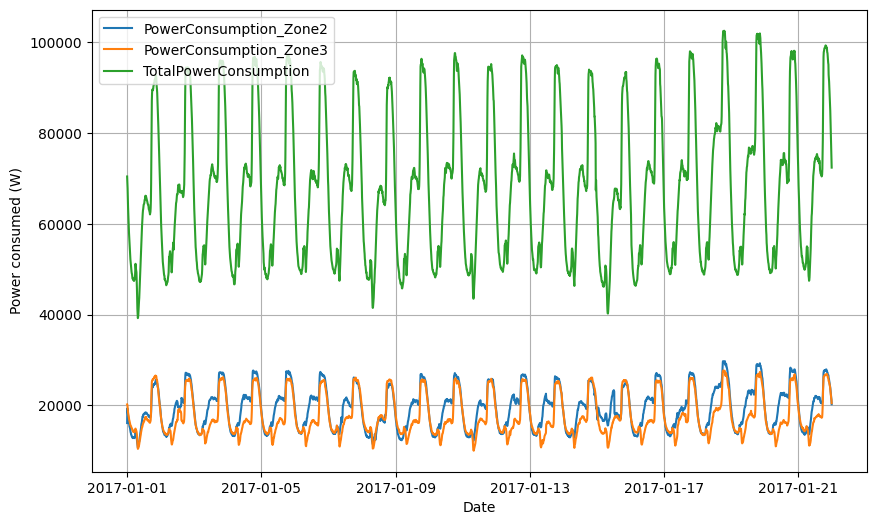

In [32]:
# Plot the date column against the three columns
plt.figure(figsize=(10, 6))
df = df_original.head(6*24*21)
for column in df.columns[-4:-1]:
    plt.plot(df['Datetime'], df[column], label=column)

# Customize the plot
plt.xlabel("Date")
plt.ylabel("Power consumed (W)")
plt.legend()
plt.grid(True)
plt.show()


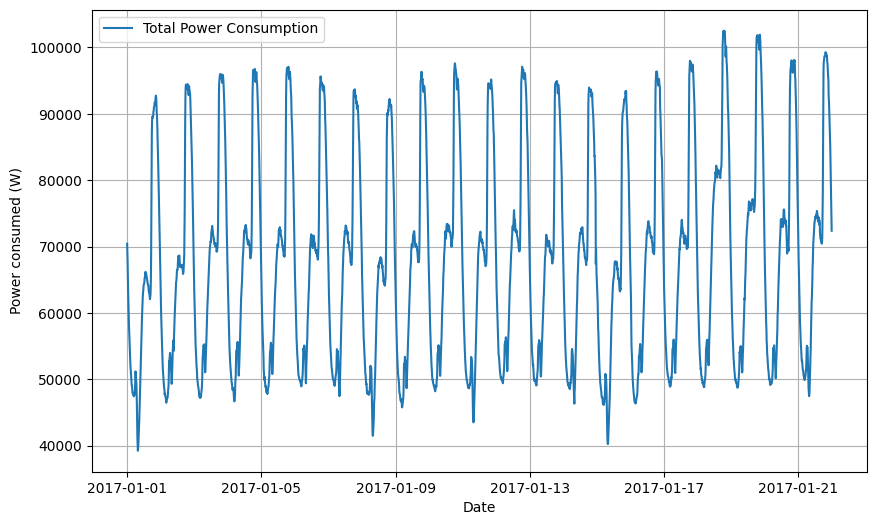

In [33]:
# Plot the date column against the three columns
plt.figure(figsize=(10, 6))
for column in df.columns[-1:]:
    plt.plot(df['Datetime'], df[column], label=column)

# Customize the plot
plt.xlabel("Date")
plt.ylabel("Power consumed (W)")
plt.legend()
plt.grid(True)
plt.show()


Get dataset information

In [34]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Datetime                 52416 non-null  object 
 1   Temperature              52416 non-null  float64
 2   Humidity                 52416 non-null  float64
 3   WindSpeed                52416 non-null  float64
 4   GeneralDiffuseFlows      52416 non-null  float64
 5   DiffuseFlows             52416 non-null  float64
 6   PowerConsumption_Zone1   52416 non-null  float64
 7   PowerConsumption_Zone2   52416 non-null  float64
 8   PowerConsumption_Zone3   52416 non-null  float64
 9   TotalPowerConsumption    52416 non-null  float64
 10  Total Power Consumption  52416 non-null  float64
dtypes: float64(10), object(1)
memory usage: 4.4+ MB


In [35]:
df_original.describe()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,TotalPowerConsumption,Total Power Consumption
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218,71222.885865,71222.885864
std,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099,17143.138964,17143.138964
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070,36785.039740,36785.039739
25%,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630,56499.074640,56499.074640
50%,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470,69788.790940,69788.790940
75%,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420,83749.172310,83749.172310
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360,134208.146000,134208.145950


Check for duplicated records using datetime column

In [36]:
duplicates = df_original[df_original.duplicated(['Datetime'])]
# duplicates
print(duplicates.count())

Datetime                   0
Temperature                0
Humidity                   0
WindSpeed                  0
GeneralDiffuseFlows        0
DiffuseFlows               0
PowerConsumption_Zone1     0
PowerConsumption_Zone2     0
PowerConsumption_Zone3     0
TotalPowerConsumption      0
Total Power Consumption    0
dtype: int64


Finding correlation using Pearson correlation coefficient

In [37]:
df = df_original.drop(columns=['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3'])
numerical_columns = df.select_dtypes(include = ['float64', 'int64'])
correlations = numerical_columns.corr()['Total Power Consumption'][:-1]
correlations

Temperature              0.488238
Humidity                -0.299059
WindSpeed                0.221706
GeneralDiffuseFlows      0.150368
DiffuseFlows             0.032068
TotalPowerConsumption    1.000000
Name: Total Power Consumption, dtype: float64

Pairplot

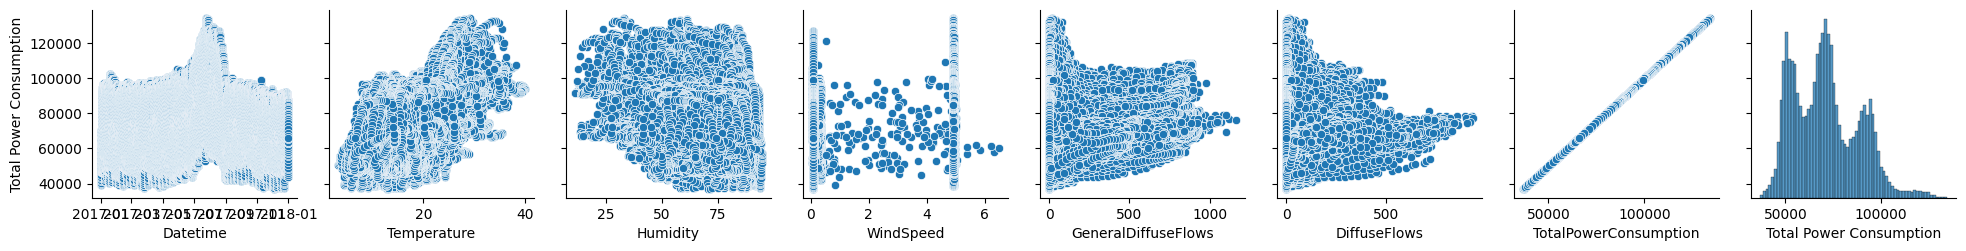

In [38]:
sns.pairplot(data=df,
            x_vars=df.columns,
            y_vars=['Total Power Consumption'])

### 2.  Feature Engineering
1.  Add weekdays and weekends, one-hot encoded
2.  Re-arrange data on hourly intervals, and make predictions on hours; 24-predictions instead of 1
3.  Derive new features from existing ones

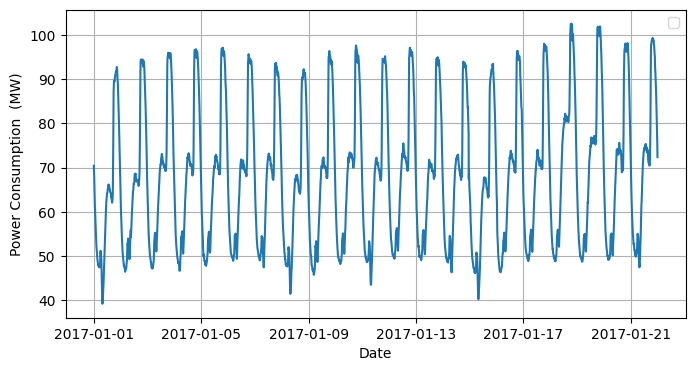

In [119]:
df = df_original.head(6*24*21)
    #     for i in range(0, 6*24*21, 6*24*7):
    # chunk = df[i:i+6*24*7]  # Extract 7-day chunk 6 because of 15 min interval
plt.figure(figsize=(8, 4))  # Create a new figure
plt.plot(df['Datetime'], df['Total Power Consumption']/1000)
plt.xlabel("Date")
plt.ylabel("Power Consumption  (MW)")
plt.grid()
plt.legend()
plt.show()

Reshape data: downsample to hourly observations, sum total power consumption, average other features
Add day of the week:  (Monday = 0, Tuesday = 1, ..., Sunday = 6).

In [120]:
def downsample_data(the_df):
    new_df = the_df.copy()

    # Set datetime as the index
    new_df.set_index("Datetime", inplace=True)

    # Resample to hourly interval and aggregate
    new_df = new_df.resample("H").agg({
        "Temperature": "mean",
        "Humidity": "mean",
        "WindSpeed": "mean",
        "GeneralDiffuseFlows": "mean",
        "DiffuseFlows": "mean",
        "Total Power Consumption": "sum",
    }).reset_index()

    # Add day of the week
    new_df["Day"] = new_df["Datetime"].dt.dayofweek

    # Separate datetime into date and hour columns
    new_df["Date"] = new_df["Datetime"].dt.date
    new_df["Hour"] = new_df["Datetime"].dt.hour

    # Drop the original datetime column if not needed
    new_df = new_df.drop(columns=["Datetime"])

    return new_df

In [121]:
downsampled_df = downsample_data(df_original)
downsampled_df.to_excel('hourly_data.xlsx', index=False)
downsampled_df.head(5)

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,Total Power Consumption,Day,Date,Hour
0,6.196833,75.066667,0.081833,0.063500,0.098833,398860.62358,6,2017-01-01,0
1,5.548833,77.583333,0.082000,0.056833,0.112500,346671.15726,6,2017-01-01,1
2,5.054333,78.933333,0.082333,0.063000,0.129167,312539.28984,6,2017-01-01,2
3,5.004333,77.083333,0.082833,0.059833,0.141000,293486.68529,6,2017-01-01,3
4,5.097667,74.050000,0.082333,0.058000,0.122833,286287.83008,6,2017-01-01,4


Check correlations after downsampling

In [122]:
numerical_columns = downsampled_df.select_dtypes(include = ['float64', 'int32'])
correlations = numerical_columns.corr()['Total Power Consumption']
correlations

Temperature                0.491780
Humidity                  -0.302248
WindSpeed                  0.224190
GeneralDiffuseFlows        0.153346
DiffuseFlows               0.036845
Total Power Consumption    1.000000
Day                       -0.064649
Hour                       0.684575
Name: Total Power Consumption, dtype: float64

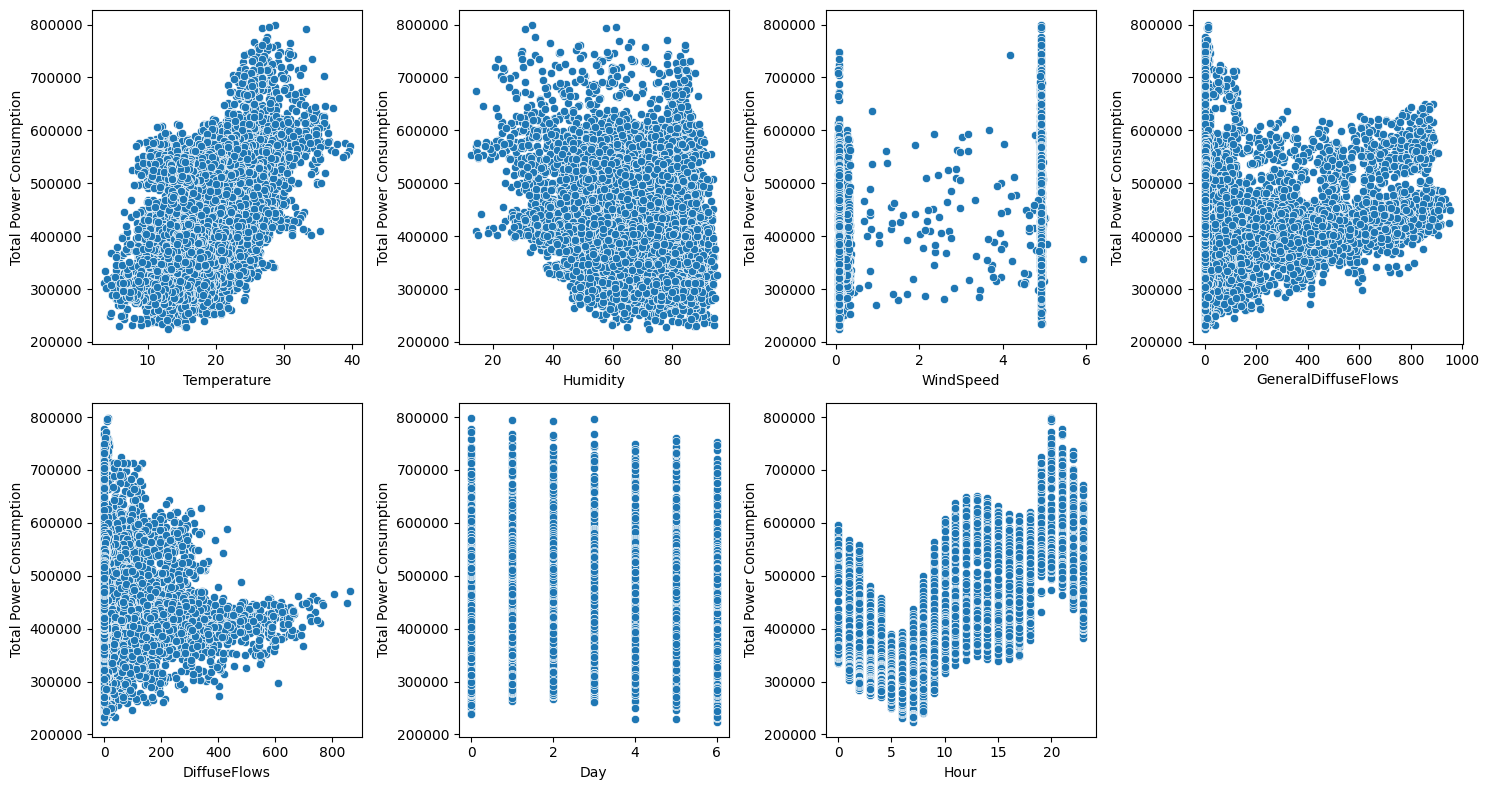

In [123]:
# Parplot
predictors = [col for col in downsampled_df.columns if col not in ['Total Power Consumption', 'Date']]

# make 2 rows
n_plots = len(predictors)
fig, axes = plt.subplots(nrows = 2, ncols = (n_plots + 1)//2, figsize = (15, 8))

axes = axes.ravel()

for ax, predictor in zip(axes.flat, predictors):
    sns.scatterplot(data = downsampled_df, x = predictor, y = 'Total Power Consumption', ax = ax)

fig.delaxes(axes[len(predictors)])
plt.tight_layout()
plt.show()
# sns.pairplot(data=downsampled_df,
#             x_vars=downsampled_df.columns,
#             y_vars=['Total Power Consumption'])

Transform data

In [124]:
seq_length = 24  # Use 24 hours for input sequence
# Prepare sequences for training
def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i:i+seq_length])
    return np.array(X_seq), np.array(y_seq)

# Overall data transformation
def transform_data(the_df, cat_columns, cont_columns, res_var):
    # One-hot encode categorical variables
    encoder = OneHotEncoder(sparse_output=False)
    encoded_cats = encoder.fit_transform(the_df[cat_columns])

    # Scale continuous variables
    scaler = MinMaxScaler()
    scaled_features = scaler.fit_transform(the_df[cont_columns])

    # Combine all features
    X = np.hstack([encoded_cats, scaled_features])
    y = the_df[res_var].values
    if len(X) < seq_length or len(y) < seq_length:
        print(f"X = {len(X)}, and y = {len(y)}.")
        return 0, 0, 0, 0
    # X_seq, y_seq = create_sequences(X, y, seq_length)

    # Split data
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_val, y_train, y_val


Define the transformer model

In [125]:
class TransformerModel(nn.Module):
    def __init__(self, input_dim, seq_length, num_heads, ff_dim, num_layers, output_dim):
        super(TransformerModel, self).__init__()
        self.transformer = nn.Transformer(
            d_model=input_dim, nhead=num_heads, num_encoder_layers=num_layers
        )
        self.fc = nn.Linear(seq_length * input_dim, output_dim)

    def forward(self, x):
        x = x.permute(1, 0, 2) 
        x = self.transformer(x, x)
        x = x.permute(1, 0, 2)  
        x = x.reshape(x.shape[0], -1)  # Flatten
        return self.fc(x)


Create a Pytorch dataset object

In [126]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [127]:
# plt.plot(range(len(validation_loss)), validation_loss, marker='o', linestyle='-', color='b')

Break a df into 24 dfs corresponding to hours

In [128]:
def split_df(the_df):
    
    # A dictionary to hold 24 hourly dfs
    hourly_dfs = {}
    for hour in range(24):
        hourly_dfs[hour] = the_df[the_df['Hour'] == hour]
    return hourly_dfs

### 3. Models' Training and Validation

#### Transform data and split it into train validation

In [129]:
# Divide unbinned data into training and validation
categorical_cols = ['Day', 'Hour']
continuous_cols = ['Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows']
response_var = 'Total Power Consumption'

X_train, X_val, y_train, y_val = transform_data(downsampled_df, categorical_cols, continuous_cols, response_var)

# Divide binned data into training and validation
hourly_X_train = {}
hourly_X_val = {}
hourly_y_train = {}
hourly_y_val = {}

categorical_cols = ['Day']
hourly_dfs = split_df(downsampled_df)

for key_hour in range(24):
    # print(key_hour)
    hourly_dfs[key_hour].drop(columns = 'Hour', inplace = True)
    hourly_X_train[key_hour], hourly_X_val[key_hour], hourly_y_train[key_hour], hourly_y_val[key_hour] = transform_data(hourly_dfs[key_hour],  categorical_cols, continuous_cols, response_var)


##### Define 3 algorithms functions

In [130]:
def poly_regression(deg, x_train, x_val, y_train, y_val):
    # Polynomial Regression
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(x_train)
    X_val_poly = poly.transform(x_val)

    # Train the model
    lin_reg = LinearRegression()
    lin_reg.fit(X_train_poly, y_train)

    # Predictions
    y_pred_poly = lin_reg.predict(X_val_poly)

    # Evaluation
    mse_poly = mean_squared_error(y_val, y_pred_poly)
    r2_poly = r2_score(y_val, y_pred_poly)
    return mse_poly, r2_poly

def xgboost_regression(x_train, x_val, y_train, y_val):
    
    # GridSearch for XGBoost Regressor
    xgb_param_grid = {'n_estimators': [50, 70, 100, 150, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2]}
    xgb_reg = XGBRegressor(objective='reg:squarederror', random_state=42)
    xgb_search = GridSearchCV(xgb_reg, xgb_param_grid, scoring='neg_mean_squared_error', cv=3)

    # Train the model
    xgb_search.fit(x_train, y_train)
    print("Best XGBoost Parameters:", xgb_search.best_params_)
    
    # Predictions
    y_pred_xgb = xgb_search.predict(x_val)

    # Evaluation
    mse_xgb = mean_squared_error(y_val, y_pred_xgb)
    r2_xgb = r2_score(y_val, y_pred_xgb)
    return mse_xgb, r2_xgb

def mlp_regression(x_train, x_val, y_train, y_val):
    # GridSearch for MLP Regressor
    mlp_param_grid = {'hidden_layer_sizes': [50, (100,), (50, 50), (16, 8), (16, 8, 4)], 'alpha': [0.0001, 0.001], 'learning_rate': ['constant', 'adaptive']}
    mlp_reg = MLPRegressor(max_iter=2500, random_state=42)
    mlp_search = GridSearchCV(mlp_reg, mlp_param_grid, scoring='neg_mean_squared_error', cv=3)
    
    # Train the model
    mlp_search.fit(x_train, y_train)
    print("Best MLP Parameters:", mlp_search.best_params_)
    
    # Predictions
    y_pred_mlp = mlp_search.predict(x_val)

    # Evaluation
    mse_mlp = mean_squared_error(y_val, y_pred_mlp)
    r2_mlp = r2_score(y_val, y_pred_mlp)
    return mse_mlp, r2_mlp


#### Experiments on Unbinned data

##### 1. Polynomial regression

In [131]:
mse_poly, r2_poly = poly_regression(2, X_train, X_val, y_train, y_val)
print(f"Polynomial Regression -> MSE: {mse_poly:.4f}, R2: {r2_poly:.4f}")


Polynomial Regression -> MSE: 1461528203.7628, R2: 0.8582


##### 2. XGBoost Regression

In [132]:
mse_xgb, r2_xgb = xgboost_regression(X_train, X_val, y_train, y_val) 
print(f"XGBoost Regression -> MSE: {mse_xgb:.4f}, R2: {r2_xgb:.4f}")


Best XGBoost Parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
XGBoost Regression -> MSE: 904966491.8369, R2: 0.9122


##### 3. Neural network regressor

In [133]:
# mse_mlp, r2_mlp = mlp_regression(X_train, X_val, y_train, y_val)
# print(f"Neural Network Regression -> MSE: {mse_mlp:.4f}, R2: {r2_mlp:.4f}")


#### Experiments on binned data

In [134]:
mse_polys = []
mse_xgbs = []
mse_mlps = []
r2_polys = []
r2_xgbs = []
r2_mlps = []

for hour in range(24):
    mse_poly, r2_poly = poly_regression(2, hourly_X_train[hour], hourly_X_val[hour], hourly_y_train[hour], hourly_y_val[hour])
    mse_polys.append(mse_poly)
    r2_polys.append(r2_poly)
    mse_xgb, r2_xgb = xgboost_regression(50, hourly_X_train[hour], hourly_X_val[hour], hourly_y_train[hour], hourly_y_val[hour]) 
    mse_xgbs.append(mse_xgb)
    r2_xgbs.append(r2_xgb)
    # mse_mlp, r2_mlp = mlp_regression((4, 2), hourly_X_train[hour], hourly_X_val[hour], hourly_y_train[hour], hourly_y_val[hour])
    # mse_mlps.append(mse_mlp)
    # r2_mlps.append(r2_mlp)


TypeError: xgboost_regression() takes 4 positional arguments but 5 were given

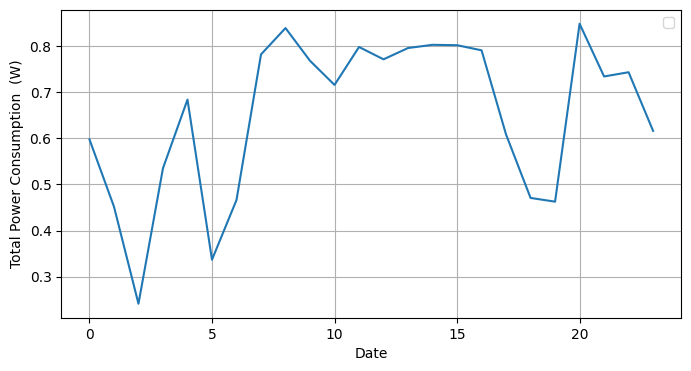

In [ ]:
plt.figure(figsize=(8, 4))  # Create a new figure
# plt.plot(r2_polys)
plt.plot(r2_xgbs)
# plt.plot(r2_mlps)
plt.xlabel("Date")
plt.ylabel("Total Power Consumption  (W)")
plt.grid()
plt.legend()
plt.show()

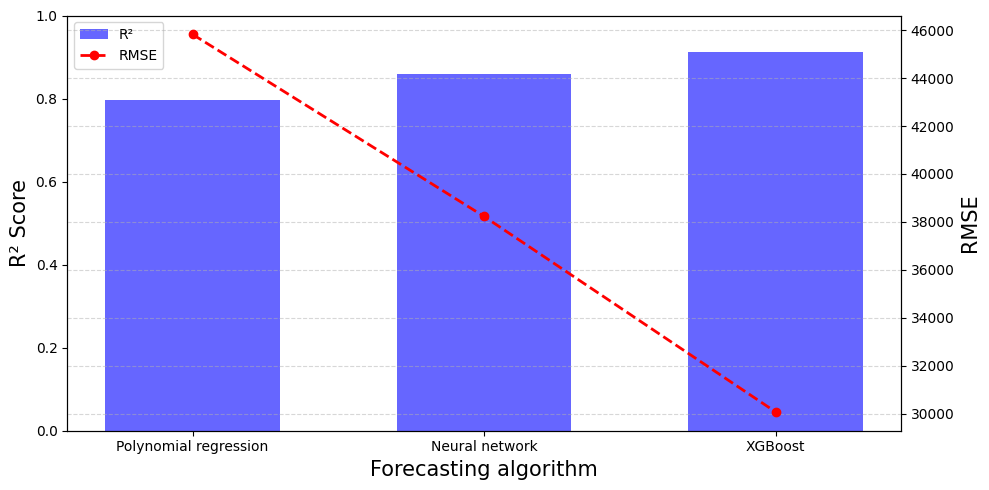

In [11]:
import matplotlib.pyplot as plt


models = ['Polynomial regression', 'Neural network', 'XGBoost']
r2_scores = [0.796, 0.858, 0.912]
rmse_scores = [45821.5, 38229.93, 30082.66]

fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot R² on the left y-axis
ax1.set_xlabel('Forecasting algorithm', fontsize=15)
ax1.set_ylabel('R² Score', fontsize=15)
bars = ax1.bar(models, r2_scores, width=0.6, color='blue', alpha=0.6, label='R²')
ax1.set_ylim(0, 1)
ax1.tick_params(axis='y')

# Create second y-axis for RMSE
ax2 = ax1.twinx()
ax2.set_ylabel('RMSE', fontsize=15)
line, = ax2.plot(models, rmse_scores, color='red', marker='o', linestyle='--', linewidth=2, label='RMSE')
ax2.tick_params(axis='y')

# Combine legends
lines_labels = [bars, line]
labels = [l.get_label() for l in lines_labels]
ax1.legend(lines_labels, labels, loc='upper left')

# Title and layout
# plt.title('R² and RMSE Comparison')
fig.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()
